In [1]:
import numpy as np
import time
from numba import njit
import matplotlib.pyplot as plt
from yennefer import RK45Solver, DOP853Solver, RADAUSolver

In [2]:
@njit
def vanderpol_stiff(t, y, params):
    mu = params[0]
    dy1 = y[1]
    dy2 = mu * (1.0 - y[0]**2) * y[1] - y[0]
    return np.array([dy1, dy2])

In [3]:
mu = 1000.0
y0 = np.array([2.0, 0.0])
params = np.array([mu])
t_max = 3000.0
dt_init = 0.01

In [4]:
def run_test(solver_class, name, **kwargs):
    solver = solver_class(vanderpol_stiff, y0, params, **kwargs)
    start = time.time()
    try:
        t, y = solver.solve(t_max, dt_init)
        end = time.time()
        print(f"{name:12} | Steps: {len(t):8} | Time: {end-start:6.3f} s | Status: Done")
        return t, y
    except Exception as e:
        print(f"{name:12} | Failed with error value: {e}")
        return None, None

In [9]:
print(f"Van der Pol oscillator evaluations comparison (mu={mu}):\n")
print(f"{'Method':12} | {'Steps':15} | {'Time':14} | {'Result'}")
print("-" * 65)

t_radau, y_radau = run_test(RADAUSolver, "RADAU", n_max_steps=1_000_000)
t_dop, y_dop     = run_test(DOP853Solver, "DOP853", n_max_steps=1_000_000)
t_rk45, y_rk45   = run_test(RK45Solver, "RK45", n_max_steps=1_000_000)

Van der Pol oscillator evaluations comparison (mu=1000.0):

Method       | Steps           | Time           | Result
-----------------------------------------------------------------
RADAU        | Steps:     5802 | Time:  0.524 s | Status: Done
DOP853       | Steps:   874937 | Time:  0.485 s | Status: Done
RK45         | Steps:  1515617 | Time:  0.571 s | Status: Done


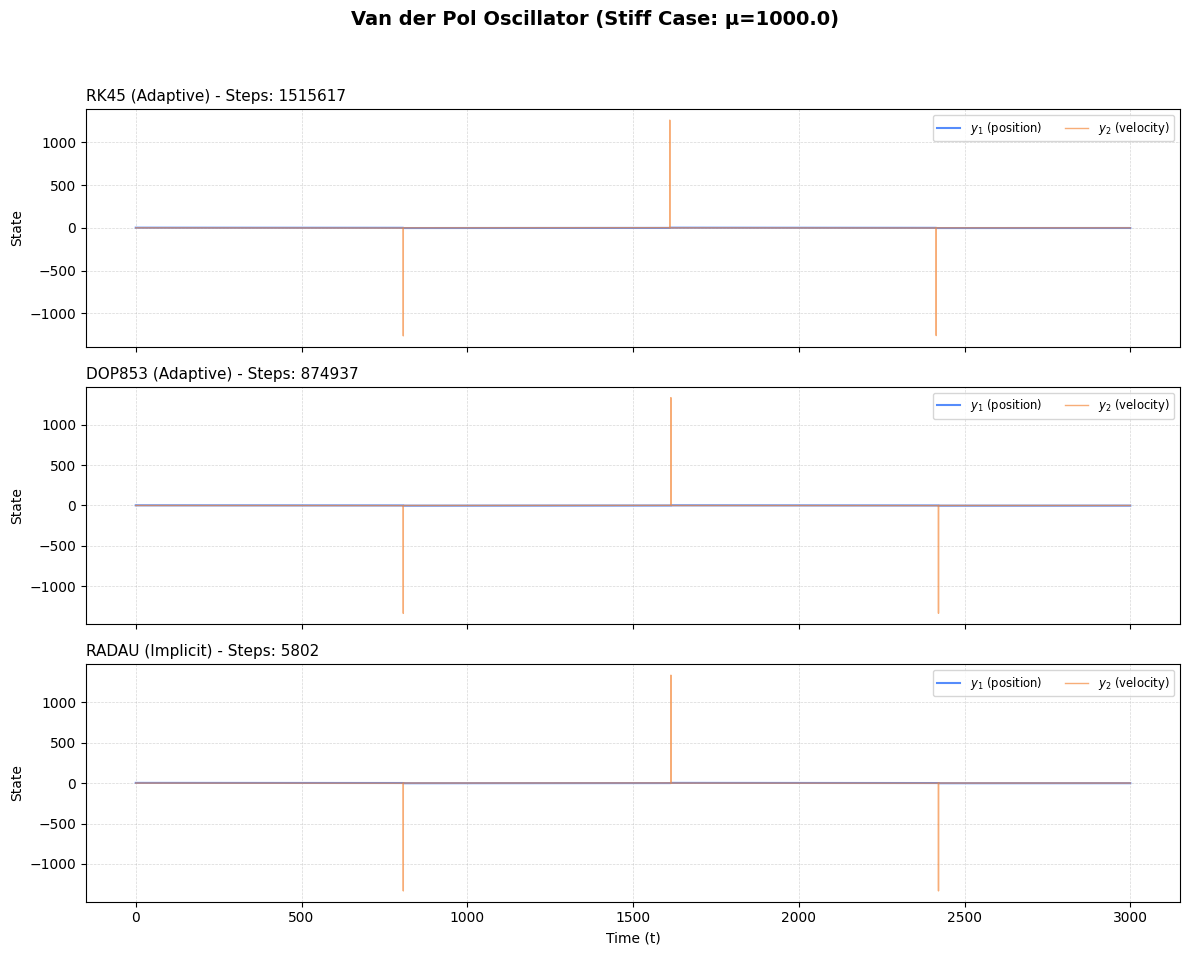

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True) # Изменил кол-во подграфиков на 3
fig.suptitle(
    f"Van der Pol Oscillator (Stiff Case: μ={mu})",
    fontsize=14, fontweight="bold",
)

configs = [
    (axes[0], t_rk45,  y_rk45,  f"RK45 (Adaptive)"),
    (axes[1], t_dop,   y_dop,   f"DOP853 (Adaptive)"),
    (axes[2], t_radau, y_radau, f"RADAU (Implicit)"),
]

for i, (ax, T, Y, title) in enumerate(configs):
    if T is not None:
        ax.plot(T, Y[:, 0], label=r"$y_1$ (position)", linewidth=1.5)
        ax.plot(T, Y[:, 1], label=r"$y_2$ (velocity)", alpha=0.7, linewidth=1.0)

        full_title = f"{title} - Steps: {len(T)}"
        ax.set_title(full_title, loc='left', fontsize=11)
        ax.set_ylabel("State")
        ax.legend(loc="upper right", fontsize='small', ncol=3)
        ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel("Time (t)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()